# *Import Library*

In [ ]:
import pandas as pd
import re
import numpy as np
import unicodedata
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from datasets import load_dataset
from wordcloud import WordCloud

C:\Users\Asus\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# *Data Wragling*

## *Gather Dataset*

In [2]:
# Load Dataset dari Hugging Face
ec_dataset = load_dataset("LuangMV97/Empathetic_counseling_Dataset")

# Cek Split yang Tersedia
print(ec_dataset.keys())

dict_keys(['train', 'test'])


In [3]:
# Ambil Data dari Split 'train'
train_data = ec_dataset['train']
# Konversi ke DataFrame
ec_train = pd.DataFrame(train_data)

In [4]:
# Ambil Data dari Split 'test'
test_data = ec_dataset['test']
# Konversi ke DataFrame
ec_test = pd.DataFrame(test_data)

In [5]:
# Gabungkan ec_train dan ec_test
ec_full = pd.concat([ec_train, ec_test], ignore_index=True)

In [6]:
# Download
ec_full.to_excel("ec_full.xlsx", index=False)

In [7]:
# Load Data
ec_full = pd.read_excel("ec_full.xlsx")

## *Assessing Dataset*

In [8]:
# Missing Value
print("=== Missing Value ===")
missing = ec_full.isnull().sum()
missing_pct = (
    missing / len(ec_full) * 100
).round(2)
missing_df = pd.DataFrame({
    "jumlah_missing": missing,
    "persentase (%)": missing_pct
})
print(missing_df)

# Duplikat
print("\n=== Duplikat ===")
exact_duplicates = ec_full[
    ec_full.duplicated(
        subset=[
            "input",
            "label"
        ],
        keep=False
    )
]
print(
    "Jumlah baris duplikat:",
    exact_duplicates.shape[0]
)
print(
    "\nJumlah pasangan unik yang duplikat:",
    exact_duplicates.drop_duplicates(
        subset=[
            "input",
            "label"
        ]
    ).shape[0]
)

# Informasi Umum
print("\n=== Informasi Umum ===")
print(ec_full.info())

=== Missing Value ===
       jumlah_missing  persentase (%)
input               0             0.0
label               0             0.0

=== Duplikat ===
Jumlah baris duplikat: 4958

Jumlah pasangan unik yang duplikat: 2037

=== Informasi Umum ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38673 entries, 0 to 38672
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   input   38673 non-null  object
 1   label   38673 non-null  object
dtypes: object(2)
memory usage: 604.4+ KB
None


## *Cleaning Dataset*

### Hapus Duplikat

In [9]:
# Hapus Duplikat, Pertahankan yang Pertama
ec = ec_full.drop_duplicates(
    subset=["input", "label"],
    keep="first"
).reset_index(drop=True)
print("\nJumlah data setelah hapus duplikat:", ec.shape)


Jumlah data setelah hapus duplikat: (35752, 2)


### *Cleaning Text & Expand Contractions*

In [10]:
# Cleaning Text & Expand contractions
contractions_dict = {
    # I (dengan apostrof)
    "i'm"       : "i am",
    "i've"      : "i have",
    "i'll"      : "i will",
    "i'd"       : "i would",
    # I (tanpa apostrof — typo/informal)
    "im"        : "i am",
    "ive"       : "i have",
    #"ill"       : "i will",   # hati-hati: "ill" juga berarti sakit
    #"id"        : "i would",  # hati-hati: "id" juga bisa noun
    # you
    "you're"    : "you are",
    "you've"    : "you have",
    "you'll"    : "you will",
    "you'd"     : "you would",
    "youre"     : "you are",
    "youve"     : "you have",
    "youll"     : "you will",
    "youd"      : "you would",
    # he
    "he's"      : "he is",
    "he'll"     : "he will",
    "he'd"      : "he would",
    "hes"       : "he is",
    "hed"       : "he would",
    # she
    "she's"     : "she is",
    "she'll"    : "she will",
    "she'd"     : "she would",
    "shes"      : "she is",
    "shed"      : "she would",
    # it
    "it's"      : "it is",
    "it'll"     : "it will",
    "it'd"      : "it would",
    #"its"       : "it is",    # hati-hati: "its" juga bisa possessive
    # we
    "we're"     : "we are",
    "we've"     : "we have",
    "we'll"     : "we will",
    "we'd"      : "we would",
    #"were"      : "we are",   # hati-hati: "were" juga past tense "be"
    "weve"      : "we have",
    "wed"       : "we would",
    # they
    "they're"   : "they are",
    "they've"   : "they have",
    "they'll"   : "they will",
    "they'd"    : "they would",
    "theyre"    : "they are",
    "theyve"    : "they have",
    "theyll"    : "they will",
    "theyd"     : "they would",
    # negations (dengan apostrof)
    "aren't"    : "are not",
    "isn't"     : "is not",
    "wasn't"    : "was not",
    "weren't"   : "were not",
    "don't"     : "do not",
    "doesn't"   : "does not",
    "didn't"    : "did not",
    "won't"     : "will not",
    "wouldn't"  : "would not",
    "can't"     : "can not",
    "cannot"    : "can not",
    "couldn't"  : "could not",
    "shouldn't" : "should not",
    "hadn't"    : "had not",
    "hasn't"    : "has not",
    "haven't"   : "have not",
    "mustn't"   : "must not",
    "needn't"   : "need not",
    "daren't"   : "dare not",
    "shan't"    : "shall not",
    # negations (tanpa apostrof — typo/informal)
    "arent"     : "are not",
    "isnt"      : "is not",
    "wasnt"     : "was not",
    "werent"    : "were not",
    "dont"      : "do not",
    "doesnt"    : "does not",
    "didnt"     : "did not",
    "wont"      : "will not",
    "wouldnt"   : "would not",
    "cant"      : "can not",
    "couldnt"   : "could not",
    "shouldnt"  : "should not",
    "hadnt"     : "had not",
    "hasnt"     : "has not",
    "havent"    : "have not",
    "mustnt"    : "must not",
    # have/would combinations (dengan apostrof)
    "that've"   : "that have",
    "who've"    : "who have",
    "would've"  : "would have",
    "could've"  : "could have",
    "should've" : "should have",
    "might've"  : "might have",
    "must've"   : "must have",
    # have/would combinations (tanpa apostrof)
    "wouldve"   : "would have",
    "couldve"   : "could have",
    "shouldve"  : "should have",
    "mightve"   : "might have",
    "mustve"    : "must have",
    # misc (dengan apostrof)
    "that's"    : "that is",
    "that'd"    : "that would",
    "there's"   : "there is",
    "there're"  : "there are",
    "there'll"  : "there will",
    "who's"     : "who is",
    "who'd"     : "who would",
    "who'll"    : "who will",
    "what's"    : "what is",
    "what're"   : "what are",
    "what'll"   : "what will",
    "what'd"    : "what did",
    "where's"   : "where is",
    "where'd"   : "where did",
    "when's"    : "when is",
    "why's"     : "why is",
    "how's"     : "how is",
    "how'd"     : "how did",
    "how'll"    : "how will",
    "let's"     : "let us",
    "y'all"     : "you all",
    # misc (tanpa apostrof)
    "thats"     : "that is",
    "theres"    : "there is",
    "whos"      : "who is",
    "whats"     : "what is",
    "wheres"    : "where is",
    "whens"     : "when is",
    "whys"      : "why is",
    "hows"      : "how is",
    "lets"      : "let us",
    "yall"      : "you all",
    # informal/slang
    "gonna"     : "going to",
    "wanna"     : "want to",
    "gotta"     : "got to",
    "kinda"     : "kind of",
    "sorta"     : "sort of",
    "dunno"     : "do not know",
    "ain't"     : "is not",
    "aint"      : "is not",
    "tryna"     : "trying to",
    "hafta"     : "have to",
    "oughta"    : "ought to",
    "supposta"  : "supposed to",
    "useta"     : "used to",
}

contractions_pattern = re.compile(
    r'\b(' + '|'.join(re.escape(k) for k in contractions_dict.keys()) + r')\b',
    re.IGNORECASE
)

def expand_contractions(text):
    def replace(match):
        token = match.group(0).lower()
        return contractions_dict.get(token, token)
    return contractions_pattern.sub(replace, text)

In [11]:
# CLEANING FUNCTION V1
# mempertahankan punctuation

def clean_text_v1(text):

    # basic
    text = str(text).lower().strip()

    # normalize unicode
    text = unicodedata.normalize(
        "NFKD",
        text
    ).encode(
        "ascii",
        "ignore"
    ).decode(
        "utf-8",
        "ignore"
    )

    # hapus URL
    text = re.sub(
        r"http\S+|www\S+",
        "",
        text
    )

    # ubah underscore jadi spasi
    text = re.sub(
        r"_+",
        " ",
        text
    )

    # expand contractions
    text = expand_contractions(text)

    # comma -> ,
    text = re.sub(
        r"\bcomma\b",
        ",",
        text
    )

    # tambah spasi setelah punctuation
    text = re.sub(
        r"([.,!?])([a-z0-9])",
        r"\1 \2",
        text
    )

    # hapus spasi sebelum punctuation
    text = re.sub(
        r"\s+([.,!?])",
        r"\1",
        text
    )

    # hapus karakter aneh
    text = re.sub(
        r"[^a-z0-9\s.,!?']",
        " ",
        text
    )

    # rapikan punctuation berulang
    text = re.sub(r"\.{2,}", ".", text)
    text = re.sub(r"!{2,}", "!", text)
    text = re.sub(r"\?{2,}", "?", text)

    # rapikan titik/koma yang terpisah
    text = re.sub(
        r"\s+,",
        ",",
        text
    )

    # rapikan multiple spaces
    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip()

    return text

# CLEANING FUNCTION V2

def clean_text_v2(text):

    # gunakan hasil cleaning v1 dulu
    text = clean_text_v1(text)

    # hapus punctuation
    text = re.sub(
        r"[^\w\s]",
        " ",
        text
    )

    # hapus apostrophe tersisa
    text = re.sub(
        r"'",
        "",
        text
    )

    # rapikan multiple spaces
    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip()

    return text

# APPLY CLEANING

# input
ec["input_clean"] = ec["input"].apply(
    clean_text_v1
)

ec["input_no_punct"] = ec["input"].apply(
    clean_text_v2
)

# label
ec["label_clean"] = ec["label"].apply(
    clean_text_v1
)

ec["label_no_punct"] = ec["label"].apply(
    clean_text_v2
)

# PREVIEW
print(
    ec[
        [
            "input_clean",
            "input_no_punct",
            "label_clean",
            "label_no_punct"
        ]
    ].head()
)

                                         input_clean  \
0                i am so annoyed at president trump.   
1  a groundhog made his way under my deck and had...   
2  as a patient, i have realized that i do not ne...   
3  i am in my early 20s, and i have been seeing m...   
4  my sister gave me 400 once but she is always b...   

                                      input_no_punct  \
0                 i am so annoyed at president trump   
1  a groundhog made his way under my deck and had...   
2  as a patient i have realized that i do not nee...   
3  i am in my early 20s and i have been seeing my...   
4  my sister gave me 400 once but she is always b...   

                                         label_clean  \
0                           i guess that is a reason   
1  do you have any pets of your own? you sound li...   
2  as a counsellor, i understand that recognizing...   
3  my first thought was that i wondered what chan...   
4  my sister gave me 400 but i know she is alw

In [12]:
# Download
ec.to_excel("ec_clean.xlsx", index=False)

In [13]:
# Load
ec = pd.read_excel("ec_clean.xlsx")

### Filter Data Khusus Putus Cinta

In [14]:
# Filter breakup score
breakup_keywords = [
    # RELATIONSHIP TERMS
    "boyfriend", "girlfriend", "bf", "gf", "partner",
    "husband", "wife", "fiance", "fiancee",
    "lover", "significant other", "spouse",
    "crush", "dating", "relationship",
    "romantic relationship", "long distance relationship",
    "ldr", "situationship",
    # BREAKUP TERMS
    "breakup", "break up", "broke up", "broken up",
    "split up", "ended things", "ended our relationship",
    "ended our friendship", "called it quits",
    "dumped", "got dumped", "left me", "left him",
    "left her", "walked away", "abandoned me",
    "moved on", "moving on", "separated",
    "divorce", "divorced", "separation",
    # EX / PAST RELATIONSHIP
    "my ex", "ex boyfriend", "ex girlfriend",
    "former boyfriend", "former girlfriend",
    "past relationship", "past lover",
    "previous relationship",
    # HEARTBREAK / LOSS
    "heartbroken", "broken heart", "hurt",
    "hurt me", "emotionally hurt",
    "devastated", "shattered", "crushed",
    "betrayed", "abandoned", "rejected",
    "unloved", "unwanted", "lonely",
    "miss him", "miss her", "miss my ex",
    "can not forget", "still love", "still miss",
    "lost him", "lost her", "can not move on",
    "crying over", "thinking about my ex",
    "thinking about him", "thinking about her",
    # CHEATING / BETRAYAL
    "cheated", "cheating", "affair",
    "unfaithful", "lied to me",
    "betrayed my trust", "two timed",
    "seeing someone else",
    "talking to another girl",
    "talking to another guy",
    # TOXIC RELATIONSHIP
    "toxic relationship", "manipulative",
    "emotionally abusive", "gaslight",
    "gaslighting", "controlling",
    "possessive", "ignored me",
    "ghosted", "blocked me",
    "silent treatment", "red flag",
    "used me", "took advantage of me",
    # ARGUMENT / CONFLICT
    "argument", "argued", "fight",
    "fighting", "fight with my boyfriend",
    "fight with my girlfriend",
    "constant fighting", "we fought",
    "we keep arguing", "misunderstanding",
    "conflict in relationship",
    # ANXIETY AFTER BREAKUP
    "overthinking him", "overthinking her",
    "anxious about relationship",
    "relationship anxiety", "fear of losing",
    "afraid to lose him", "afraid to lose her",
    "worried he will leave", "worried she will leave",
    "attachment issues", "clingy", "insecure relationship",
    # ACCEPTANCE / HEALING
    "healing", "recovering", "trying to move on",
    "self love", "letting go", "finding peace", "closure",
    "finally okay", "feeling better", "accepting the breakup",
    "learning to be alone", "working on myself",
    "focusing on myself", "becoming independent",
    # SOCIAL MEDIA / MODERN TERMS
    "seen zoned", "friend zoned", "unfollowed me",
    "blocked me", "removed me", "texted my ex",
    "stalk my ex", "checking his profile", "checking her profile",
    # COMMON EXPRESSIONS
    "he does not love me", "she does not love me",
    "he stopped talking to me", "she stopped talking to me",
    "he lost feelings", "she lost feelings",
    "i miss my relationship", "i feel alone after breakup",
    "i can not stop thinking about him",
    "i can not stop thinking about her",
    "i want him back", "i want her back",
    "i still care about him", "i still care about her"
]

breakup_anger_keywords = [
    "cheated", "cheating", "affair", "unfaithful", "lied to me",
    "betrayed", "betrayed my trust", "two timed", "manipulative",
    "gaslighting", "controlling", "toxic relationship", "emotionally abusive",
    "used me", "took advantage of me", "ghosted", "blocked me",
    "silent treatment", "red flag", "possessive", "ignored me",
    "argument", "argued", "fight", "fighting", "we fought",
    "constant fighting", "endless arguments"
]

breakup_anxiety_keywords = [
    "miss him", "miss her", "miss my ex", "still love", "still miss",
    "can not forget", "can not move on", "thinking about him",
    "thinking about her", "thinking about my ex", "i want him back",
    "i want her back", "i still care about him", "i still care about her",
    "overthinking him", "overthinking her", "relationship anxiety",
    "fear of losing", "afraid to lose him", "afraid to lose her",
    "worried he will leave", "worried she will leave",
    "attachment issues", "clingy", "insecure relationship",
    "heartbroken", "broken heart", "devastated", "shattered", "crushed",
    "lonely", "unloved", "unwanted", "lost him", "lost her",
    "crying over", "stalk my ex", "checking his profile", "checking her profile"
]

breakup_acceptance_keywords = [
    "healing", "recovering", "trying to move on", "self love",
    "letting go", "finding peace", "closure", "finally okay",
    "feeling better", "accepting the breakup", "learning to be alone",
    "working on myself", "focusing on myself", "becoming independent",
    "starting over", "fresh start", "new chapter", "new beginning",
    "getting over him", "getting over her", "slowly healing"
]

In [15]:
# BREAKUP SCORE FUNCTION
def get_breakup_score(text, keywords):

    text = str(text).lower()

    score = 0

    for keyword in keywords:

        pattern = (
            r"\b" +
            re.escape(keyword.lower()) +
            r"\b"
        )

        if re.search(pattern, text):

            score += 1

    return score


# HITUNG BREAKUP SCORE
# menggunakan kolom input_no_punct

ec["breakup_score"] = ec["input_no_punct"].apply(
    lambda x: get_breakup_score(
        x,
        breakup_keywords
    )
)

# FILTER DATA BREAKUP
# minimal mengandung 2 keyword breakup

ec_breakup = ec[
    ec["breakup_score"] >= 2
].copy().reset_index(drop=True)


# INFORMASI FILTERING

print(f"Sebelum filter : {len(ec):,} baris")

print(f"Sesudah filter : {len(ec_breakup):,} baris")

print(
    f"Dihapus        : "
    f"{len(ec) - len(ec_breakup):,} baris"
)

# PREVIEW

print(
    ec_breakup[
        [
            "input_clean",
            "breakup_score"
        ]
    ].head()
)

Sebelum filter : 35,752 baris
Sesudah filter : 1,336 baris
Dihapus        : 34,416 baris
                                         input_clean  breakup_score
0  my fiance and i have been together for 3 years...              4
1  i caught my wife red handed cheating on me i f...              2
2  we live with my ex partners sister and her hus...              2
3  hello, i have a cousin in my family who has be...              2
4  i am concerned about my current long distance ...              4


In [16]:
# Download
ec_breakup.to_excel("ec_breakup.xlsx", index=False)

In [29]:
# Load
ec_breakup = pd.read_excel("ec_breakup.xlsx")

# Pertanyaan Bisnis

1. Emosi apa yang paling dominan muncul dalam percakapan breakup berdasarkan distribusi hasil klasifikasi pada dataset Healmate AI?

2. Kata-kata emosional apa yang paling sering muncul pada masing-masing kategori emosi (*anger*, *anxiety*, dan *acceptance*) berdasarkan analisis frekuensi kata pada dataset?


# *EDA & Visualization*

## *Feature Engineering*

### *Emotion Lexicon*

In [30]:
anger_words = [
    "mad",
    "pissed",
    "pissed off",
    "angry",
    "annoyed",
    "frustrated",
    "furious",
    "irritated",
    "bitter",
    "salty",
    "resentful",
    "hurt",
    "betrayed",
    "disappointed",
    "fed up",
    "done",
    "sick of it",
    "upset",
    "triggered",
    "grudge"
]

anxiety_words = [
    "anxious",
    "worried",
    "overthinking",
    "scared",
    "afraid",
    "nervous",
    "restless",
    "uneasy",
    "insecure",
    "unsure",
    "confused",
    "paranoid",
    "stressed",
    "overwhelmed",
    "clingy",
    "doubtful",
    "hesitant",
    "obsessive",
    "stuck",
    "spiraling"
]

acceptance_words = [
    "move",
    "closure",
    "accept",
    "forgive",
    "heal",
    "let",
    "peace",
    "release",
    "okay",
    "realize",
    "learn",
    "better",
    "relief",
    "independent",
    "start",
    "strong",
    "understand",
    "grow",
    "enough",
    "change"
]

emotion_dict = {
    "anger": anger_words,
    "anxiety": anxiety_words,
    "acceptance": acceptance_words
}

In [ ]:
# PREPROCESSING UNTUK EMOTION DETECTION

def preprocess_for_emotion(text):

    text = str(text).lower()

    # hanya simpan huruf dan spasi
    text = re.sub(
        r"[^a-z\s]",
        " ",
        text
    )

    # rapikan spasi
    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip()

    return text.split()


# HEURISTIC BERDASARKAN STRUKTUR KALIMAT

def detect_structure_emotion(text):

    text = str(text).lower()

    scores = {
        "anger": 0,
        "anxiety": 0,
        "acceptance": 0
    }

    # anxiety patterns

    if re.search(
        r"\b(why|what if|how could|where did|when will|should i|what do i do)\b",
        text
    ):
        scores["anxiety"] += 2

    # anger patterns

    if re.search(
        r"\b(he lied|she lied|how dare|i hate|never again|so done)\b",
        text
    ):
        scores["anger"] += 2

    # acceptance patterns

    if re.search(
        r"\b(i am okay|i am fine|i am better|i am moving on|i am healing|i am done crying)\b",
        text
    ):
        scores["acceptance"] += 2

    # he/she + negative action -> anger

    if re.search(
        r"\b(he|she)\b.{0,20}\b(left|lied|cheated|hurt|ignored|blocked|ghosted)\b",
        text
    ):
        scores["anger"] += 1

    # i + longing -> anxiety

    if re.search(
        r"\bi\b.{0,20}\b(miss|wish|hope|want|need|think about)\b",
        text
    ):
        scores["anxiety"] += 1

    return scores


# EMOTION PROBABILITY FUNCTION

def calculate_emotion_probabilities(text):

    tokens = preprocess_for_emotion(text)

    token_counts = Counter(tokens)

    scores = {
        "anger": 0,
        "anxiety": 0,
        "acceptance": 0
    }

    text_lower = str(text).lower()

    # LAYER 1
    
    for emotion, vocab_list in emotion_dict.items():

        for word in vocab_list:

            # multi-word keyword
            if " " in word:

                pattern = (
                    r"\b" +
                    re.escape(word.lower()) +
                    r"\b"
                )

                matches = re.findall(
                    pattern,
                    text_lower
                )

                scores[emotion] += len(matches)

            # single-word keyword
            else:

                if word in token_counts:

                    scores[emotion] += (
                        token_counts[word]
                    )

    # LAYER 2
    # breakup keyword context

    if all(score == 0 for score in scores.values()):

        for kw in breakup_anger_keywords:

            if re.search(
                r"\b" + re.escape(kw) + r"\b",
                text_lower
            ):
                scores["anger"] += 1

        for kw in breakup_anxiety_keywords:

            if re.search(
                r"\b" + re.escape(kw) + r"\b",
                text_lower
            ):
                scores["anxiety"] += 1

        for kw in breakup_acceptance_keywords:

            if re.search(
                r"\b" + re.escape(kw) + r"\b",
                text_lower
            ):
                scores["acceptance"] += 1

    # LAYER 3
    # sentence structure heuristic

    if all(score == 0 for score in scores.values()):

        structure_scores = detect_structure_emotion(text)

        for emotion in scores:

            scores[emotion] += (
                structure_scores[emotion]
            )

    # BONUS / PENALTY

    # acceptance penalty
    negative_strength = (
        scores["anger"] +
        scores["anxiety"]
    )

    if negative_strength > 0:

        scores["acceptance"] *= 0.35

    # bonus anxiety jika banyak tanda tanya
    qmark_count = str(text).count("?")

    scores["anxiety"] += (
        qmark_count * 0.5
    )

    # bonus anger jika banyak tanda seru
    exclaim_count = str(text).count("!")

    scores["anger"] += (
        exclaim_count * 0.3
    )

    # TIE BREAKER

    # kalau semua skor 0
    if all(score == 0 for score in scores.values()):

        scores["anxiety"] += 0.05

    # SMOOTHING

    for emotion in scores:

        scores[emotion] += 0.01

    # SOFTMAX NORMALIZATION

    exp_scores = {
        emotion: np.exp(score)
        for emotion, score in scores.items()
    }

    total = sum(exp_scores.values())

    probs = {
        f"{emotion}_prob": (
            exp_scores[emotion] / total
        )
        for emotion in exp_scores
    }

    return pd.Series(probs)

# HITUNG PROBABILITAS EMOSI

print("\n[i] Menghitung probabilitas emosi...")

emotion_probs = ec_breakup["input_clean"].apply(
    calculate_emotion_probabilities
)

emotion_cols = [
    "anger_prob",
    "anxiety_prob",
    "acceptance_prob"
]

# GABUNGKAN HASIL

ec_eda = pd.concat(
    [
        ec_breakup[
            [
                "input_clean",
                "label_clean",
                "input_no_punct",
                "label_no_punct",
                "breakup_score"
            ]
        ].reset_index(drop=True),

        emotion_probs.reset_index(drop=True)
    ],
    axis=1
)

# PREDICTED EMOTION

ec_eda["predicted_emotion"] = (
    ec_eda[emotion_cols]
    .idxmax(axis=1)
    .str.replace(
        "_prob",
        "",
        regex=False
    )
)

# EMOTION CONFIDENCE

ec_eda["emotion_confidence"] = (
    ec_eda[emotion_cols]
    .max(axis=1)
)

# FINAL DATASET

ec_eda = ec_eda[
    [
        "input_clean",
        "label_clean",
        "input_no_punct",
        "label_no_punct",
        "breakup_score",
        "anger_prob",
        "anxiety_prob",
        "acceptance_prob",
        "predicted_emotion",
        "emotion_confidence"
    ]
]

# PREVIEW

print(ec_eda.head())


[i] Menghitung probabilitas emosi...
                                         input_clean  \
0  my fiance and i have been together for 3 years...   
1  i caught my wife red handed cheating on me i f...   
2  we live with my ex partners sister and her hus...   
3  hello, i have a cousin in my family who has be...   
4  i am concerned about my current long distance ...   

                                         label_clean  \
0  finding out about an affair is quite an emotio...   
1  i could not move my body. i fainted because sh...   
2  hi new york, i am happy to hear that your daug...   
3  it sounds like you are feeling pretty criticiz...   
4  it is important to communicate your concerns w...   

                                      input_no_punct  \
0  my fiance and i have been together for 3 years...   
1  i caught my wife red handed cheating on me i f...   
2  we live with my ex partners sister and her hus...   
3  hello i have a cousin in my family who has bee...   
4  i am 

In [32]:
# Predicted emotion & confidence
CONFIDENCE_THRESHOLD = 0.34

def predict_emotion(row):
    probs = {
        "anger"      : row["anger_prob"],
        "anxiety"    : row["anxiety_prob"],
        "acceptance" : row["acceptance_prob"],
    }
    max_emotion = max(probs, key=probs.get)
    max_prob    = probs[max_emotion]

    if max_prob < CONFIDENCE_THRESHOLD:
        return "unclear"

    return max_emotion

ec_eda["predicted_emotion"]  = ec_eda.apply(predict_emotion, axis=1)
ec_eda["emotion_confidence"] = ec_eda[emotion_cols].max(axis=1)

In [33]:
# Distribusi Emosi
emotion_counts = ec_eda["predicted_emotion"].value_counts()
print("\n=== Distribusi Emosi ===")
print(emotion_counts)


=== Distribusi Emosi ===
predicted_emotion
anxiety       657
anger         471
acceptance    208
Name: count, dtype: int64


In [34]:
# Preview
print("\n=== Preview Data ===")
print(
    ec_eda[
        [
            "input_clean",
            "label_clean",
            "anger_prob",
            "anxiety_prob",
            "acceptance_prob",
            "predicted_emotion",
            "emotion_confidence"
        ]
    ].head(10)
)


=== Preview Data ===
                                         input_clean  \
0  my fiance and i have been together for 3 years...   
1  i caught my wife red handed cheating on me i f...   
2  we live with my ex partners sister and her hus...   
3  hello, i have a cousin in my family who has be...   
4  i am concerned about my current long distance ...   
5  my spouse had a brief affair last year. it end...   
6  i feel like there are different times where i ...   
7  i had to put a restraining order against my ex...   
8  my wife is always accusing me of cheating and ...   
9  i have a troubled relationship with my mother ...   

                                         label_clean  anger_prob  \
0  finding out about an affair is quite an emotio...    0.133414   
1  i could not move my body. i fainted because sh...    0.576117   
2  hi new york, i am happy to hear that your daug...    0.576117   
3  it sounds like you are feeling pretty criticiz...    0.785597   
4  it is important to

In [ ]:
# Download
ec_eda.to_excel("Empathetic Counseling.xlsx", index=False)

In [38]:
# Load
ec_eda = pd.read_excel("Empathetic Counseling.xlsx")

## *Visualization*

### Bar Chart Distribusi Emosi

In [40]:
# Hitung distribusi emosi
emotion_distribution = (
    ec_eda["predicted_emotion"]
    .value_counts()
)

C:\Users\Asus\AppData\Local\Temp\ipykernel_14308\2118556352.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


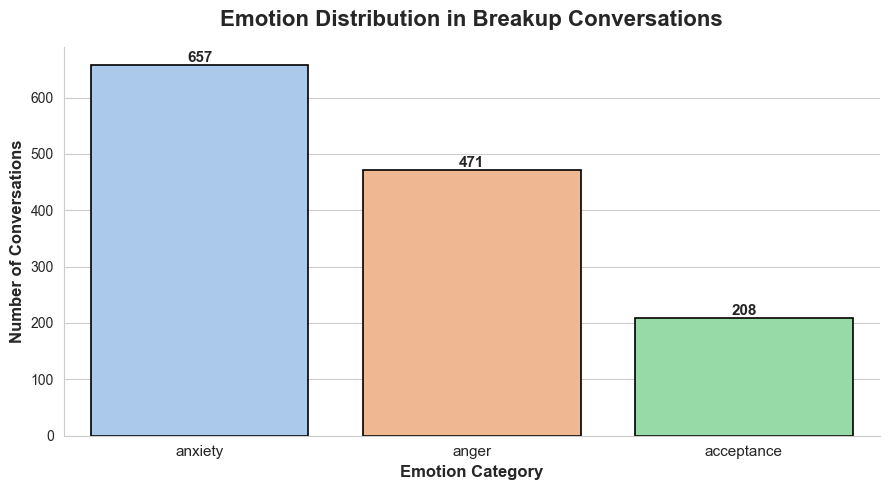

In [41]:
# Style
sns.set_style("whitegrid")

# Figure
plt.figure(figsize=(9, 5))

ax = sns.countplot(
    data=ec_eda,
    x="predicted_emotion",
    order=emotion_distribution.index,
    palette="pastel",
    edgecolor="black",
    linewidth=1.2
)

# Title & Labels
plt.title(
    "Emotion Distribution in Breakup Conversations",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Emotion Category",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Number of Conversations",
    fontsize=12,
    fontweight="bold"
)

# Add value labels
for p in ax.patches:

    ax.annotate(
        f"{int(p.get_height())}",
        (
            p.get_x() + p.get_width() / 2,
            p.get_height()
        ),
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

# Grid & layout
plt.xticks(
    fontsize=11
)

plt.yticks(
    fontsize=10
)

sns.despine()

plt.tight_layout()

plt.show()

### *Word Cloud*

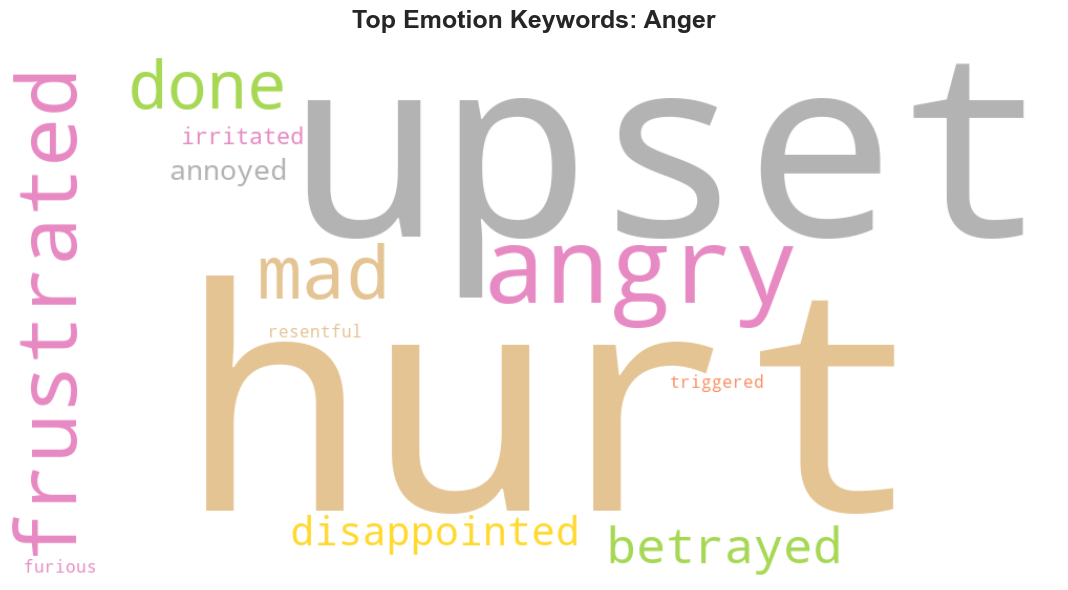

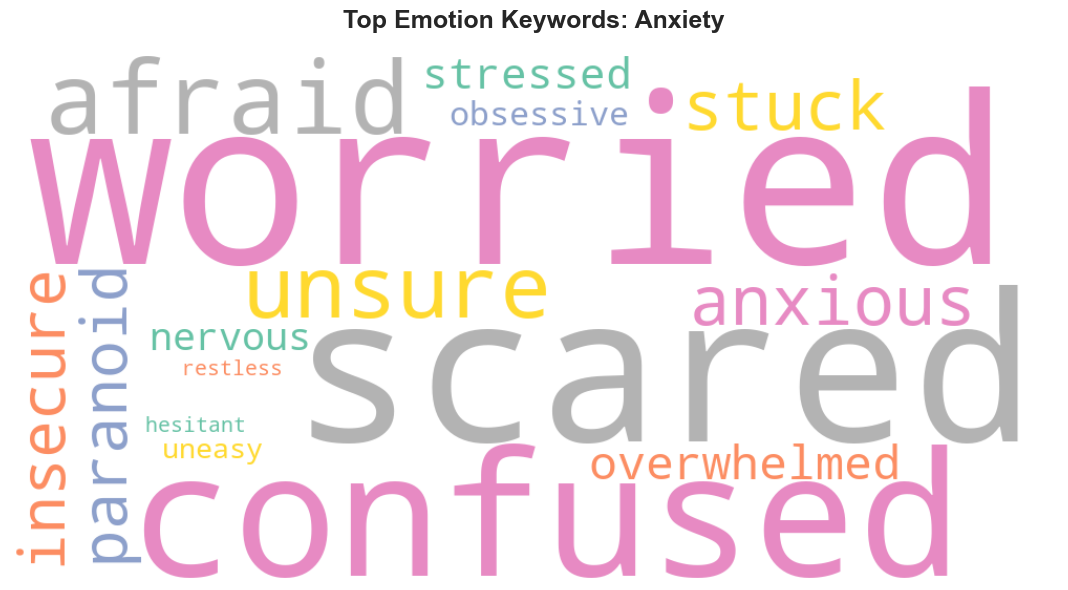

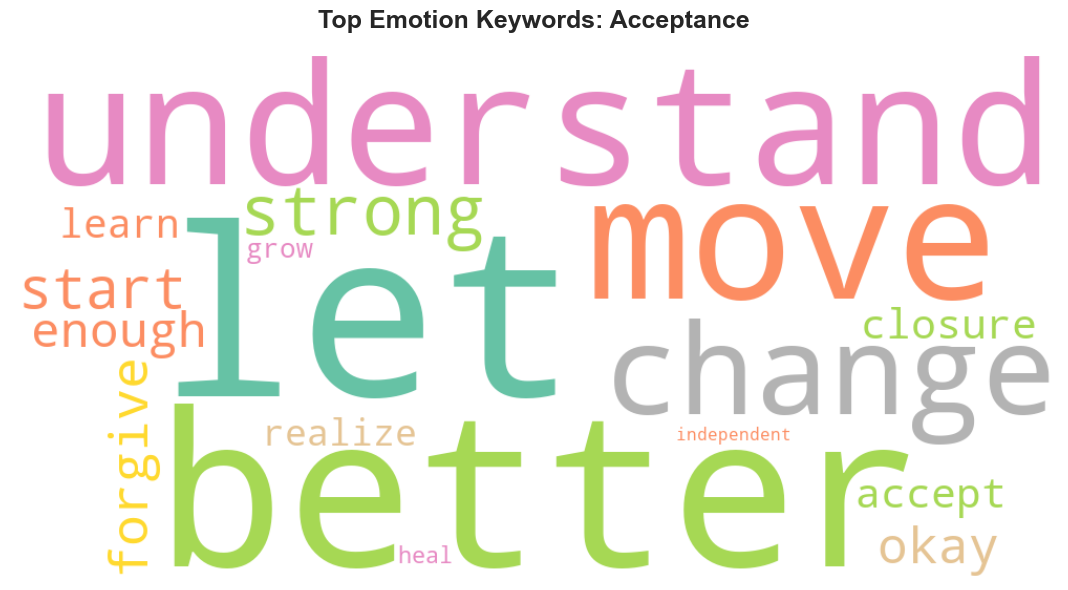

In [42]:
# Emotion Keywords Only
emotion_keywords = {
    "anger": anger_words,
    "anxiety": anxiety_words,
    "acceptance": acceptance_words
}

# WordCloud per Emotion
for emotion in emotion_keywords.keys():

    # ambil text sesuai emosi
    texts = ec_eda[
        ec_eda["predicted_emotion"] == emotion
    ]["input_no_punct"].fillna("")

    # gabungkan semua text
    combined_text = " ".join(texts)

    # tokenize
    words = re.findall(r"\b[a-z]+\b", combined_text.lower())

    # filter hanya kata emosi
    filtered_words = [
        word
        for word in words
        if word in emotion_keywords[emotion]
    ]

    # hitung frekuensi
    word_freq = Counter(filtered_words)

    # skip kalau kosong
    if len(word_freq) == 0:
        continue

    # WordCloud

    wordcloud = WordCloud(
        width=1000,
        height=500,
        background_color="white",
        colormap="Set2",
        max_words=50,
        contour_width=1,
        contour_color="black"
    ).generate_from_frequencies(word_freq)

    # Plot
    plt.figure(figsize=(12, 6))

    plt.imshow(
        wordcloud,
        interpolation="bilinear"
    )

    plt.axis("off")

    plt.title(
        f"Top Emotion Keywords: {emotion.capitalize()}",
        fontsize=18,
        fontweight="bold",
        pad=20
    )

    plt.tight_layout()

    plt.show()

### Histogram Plot Distribusi *Confidence Score*

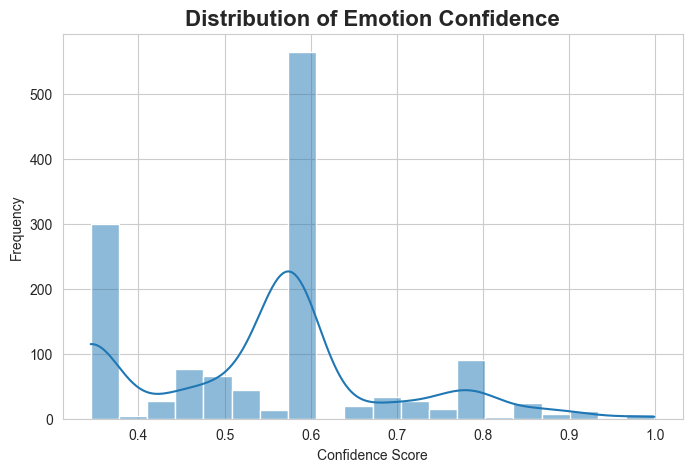

In [43]:
plt.figure(figsize=(8,5))

sns.histplot(
    ec_eda["emotion_confidence"],
    bins=20,
    kde=True
)

plt.title(
    "Distribution of Emotion Confidence",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Confidence Score")
plt.ylabel("Frequency")

plt.show()

### Pie Chart Distribusi Emosi

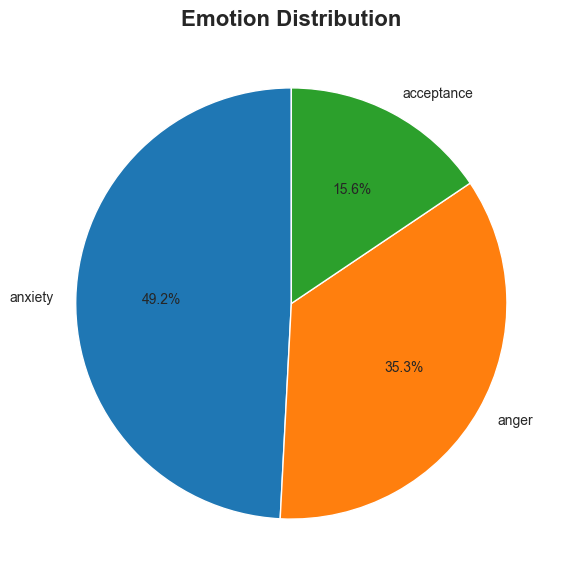

In [44]:
emotion_distribution = (
    ec_eda["predicted_emotion"]
    .value_counts()
)

plt.figure(figsize=(7,7))

plt.pie(
    emotion_distribution.values,
    labels=emotion_distribution.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Emotion Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.show()

### *Top Words* setiap Emosi

C:\Users\Asus\AppData\Local\Temp\ipykernel_14308\2359760643.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


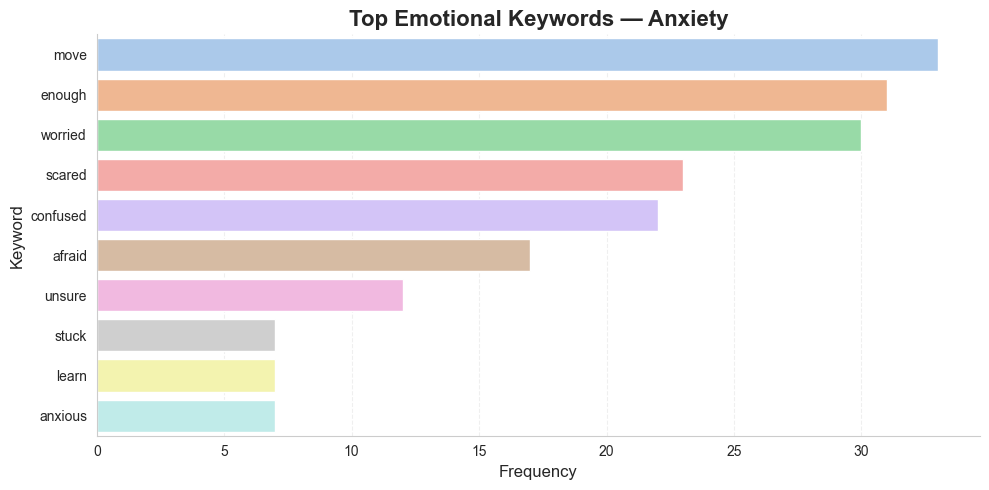

C:\Users\Asus\AppData\Local\Temp\ipykernel_14308\2359760643.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


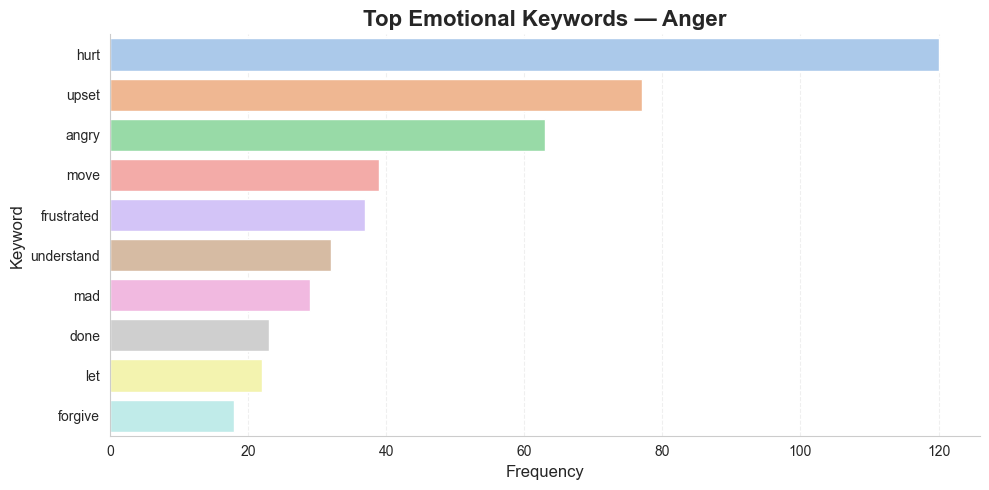

C:\Users\Asus\AppData\Local\Temp\ipykernel_14308\2359760643.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


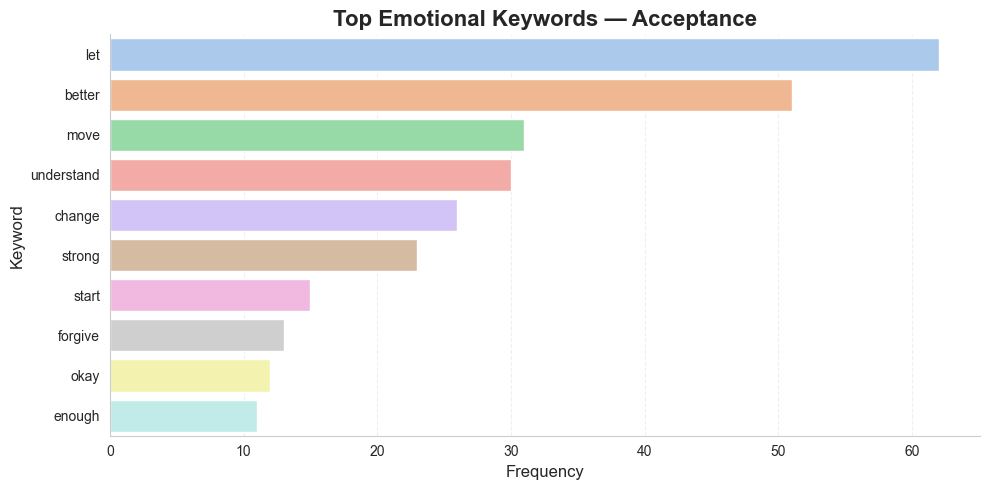

In [46]:
# Gabungkan semua emotion words
emotion_vocab = set(
    anger_words +
    anxiety_words +
    acceptance_words
)

# Custom stopwords
custom_stopwords = set([
    "feel", "feels", "feeling",
    "felt", "really", "know",
    "think", "want", "like",
    "just", "thing", "things",
    "people", "person", "time",
    "going", "go", "still",
    "would", "could", "also"
])

# Top Emotional Words per Emotion
emotions = (
    ec_eda["predicted_emotion"]
    .unique()
)

for emotion in emotions:

    # Ambil text berdasarkan emosi
    text = " ".join(
        ec_eda[
            ec_eda["predicted_emotion"] == emotion
        ]["input_no_punct"].fillna("")
    )

    words = text.split()

    # Filter kata
    filtered_words = [

        word for word in words

        if (
            word in emotion_vocab
            and word not in custom_stopwords
        )
    ]

    # Hitung frekuensi
    common_words = (
        Counter(filtered_words)
        .most_common(10)
    )

    words_df = pd.DataFrame(
        common_words,
        columns=["word", "count"]
    )

    # Plot
    plt.figure(figsize=(10, 5))

    sns.barplot(
        data=words_df,
        x="count",
        y="word",
        palette="pastel"
    )

    plt.title(
        f"Top Emotional Keywords — {emotion.capitalize()}",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel(
        "Frequency",
        fontsize=12
    )

    plt.ylabel(
        "Keyword",
        fontsize=12
    )

    plt.grid(
        axis="x",
        linestyle="--",
        alpha=0.3
    )

    sns.despine()

    plt.tight_layout()

    plt.show()